# 📊 Data Storytelling & Executive Business Insights

## ApexPlanet Data Analytics Internship

### Task 4 — Data Storytelling & Statistical Validation

---

## Business Objective

This notebook transforms analytical findings into actionable business insights by integrating results from:

- Data Cleaning & Preparation
- Exploratory Data Analysis (EDA)
- SQL Business Intelligence
- Statistical Validation
- Interactive Power BI Dashboard

Rather than focusing on technical analysis, this notebook communicates findings from a business perspective to support strategic decision-making.

---

## Business Questions Addressed

This report answers the following key questions:

1. What are the primary drivers of business revenue?
2. Which products and categories generate the highest sales?
3. Which customer segments contribute the most revenue?
4. Which geographic regions perform best?
5. How does revenue change over time?
6. Which KPIs should management monitor?
7. What strategic actions can improve future business performance?

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)


In [2]:
df = pd.read_csv("../data/processed/cleaned_dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.00,Female,Bengaluru,Rice,Grocery,7,"2,829.77","19,808.39",Young
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.00,Male,Bengaluru,Book,Education,5,"27,906.16","139,530.80",Senior
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.00,Female,Bengaluru,Book,Education,8,"37,491.06","299,928.48",Senior
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.00,Female,Kolkata,Mobile,Electronics,9,"28,541.36","256,872.24",Senior
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.00,Male,Bengaluru,Rice,Grocery,10,"14,036.59","140,365.90",Adult


# Executive KPI Story

## Business Overview

Key Performance Indicators (KPIs) provide a high-level summary of business performance and serve as the foundation for executive decision-making.

The following KPIs answer critical business questions:

- How much revenue was generated?
- How many orders were completed?
- How many unique customers made purchases?
- How many products were sold?
- What is the average value of each order?
- How much revenue does each customer generate on average?

Together, these indicators provide an overall assessment of business health before performing deeper analysis.

In [3]:
total_revenue = df["Total_Sales"].sum()

total_orders = df["Order_ID"].nunique()

total_customers = df["Customer_ID"].nunique()

total_quantity = df["Quantity"].sum()

average_order_value = total_revenue / total_orders

revenue_per_customer = total_revenue / total_customers

kpi_df = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Unique Customers",
        "Quantity Sold",
        "Average Order Value",
        "Revenue per Customer"
    ],
    "Value": [
        f"₹{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{total_quantity:,}",
        f"₹{average_order_value:,.2f}",
        f"₹{revenue_per_customer:,.2f}"
    ]
})

kpi_df

,KPI,Value
0,Total Revenue,"₹139,399,439.65"
1,Total Orders,992
2,Unique Customers,947
3,Quantity Sold,"5,435"
4,Average Order Value,"₹140,523.63"
5,Revenue per Customer,"₹147,201.10"


In [4]:
display(
    kpi_df.style
        .hide(axis="index")
        .set_caption("Executive KPI Summary")
)

KPI,Value
Total Revenue,"₹139,399,439.65"
Total Orders,992
Unique Customers,947
Quantity Sold,"5,435"
Average Order Value,"₹140,523.63"
Revenue per Customer,"₹147,201.10"


# Executive KPI Analysis

The Executive KPI Summary provides a consolidated view of the organization's overall business performance during the analysis period.

These indicators serve as the foundation for evaluating operational efficiency, customer engagement, and revenue generation before performing detailed business analysis.

---

## Revenue Performance

The business generated a **Total Revenue of ₹139.40 Million**, demonstrating strong sales performance across products, customer segments, and geographic markets.

This revenue reflects the combined impact of product pricing, customer demand, and purchasing behavior.

---

## Sales Activity

A total of **992 unique customer orders** were successfully completed.

The relatively high number of completed transactions indicates healthy customer engagement and consistent sales activity throughout the reporting period.

---

## Customer Base

The organization served **947 unique customers**, suggesting a broad customer reach.

Since the number of customers is close to the number of orders, the dataset indicates that most customers made a single purchase during the observed period, highlighting an opportunity to improve customer retention and repeat purchases.

---

## Sales Volume

A total of **5,435 products** were sold across all product categories.

This reflects steady purchasing activity and demonstrates that revenue generation is supported by both transaction frequency and product demand.

---

## Average Order Value (AOV)

The **Average Order Value (AOV)** is approximately **₹140,523.63**.

This indicates that each completed order generates substantial revenue, suggesting that customers frequently purchase premium-priced products or multiple items per transaction.

Maintaining or increasing AOV should remain a strategic business objective.

---

## Revenue per Customer

Each customer generated an average revenue of approximately **₹147,201.10**.

This metric highlights the monetary value of the average customer and provides a benchmark for evaluating customer acquisition costs, retention strategies, and lifetime value initiatives.

---

## Executive Summary

The KPI analysis indicates a financially healthy business characterized by:

- Strong overall revenue generation.
- High-value customer transactions.
- A broad and diverse customer base.
- Consistent purchasing activity across multiple product categories.

The close relationship between total customers and total orders suggests significant opportunities to improve customer retention, increase repeat purchases, and enhance customer lifetime value through personalized marketing and loyalty programs.

# Key Executive Insights

Based on the Executive KPI analysis, the following strategic observations can be made:

## Strengths

- Generated **₹139.40 Million** in total revenue.
- Maintained a healthy Average Order Value of **₹140.52K**.
- Achieved strong customer acquisition with **947 unique customers**.
- Sustained consistent sales volume across the reporting period.

---

## Opportunities

- Increase repeat purchases through customer loyalty initiatives.
- Improve customer lifetime value with personalized marketing campaigns.
- Encourage larger basket sizes through product bundling and cross-selling.
- Expand high-performing product categories and regional markets.

---

## Business Impact

These KPIs establish a strong performance baseline for the detailed analyses presented in the following sections, including revenue trends, customer behavior, product performance, and regional sales analysis.

# Revenue Story

## Business Context

Revenue is the most critical indicator of business performance.

Understanding how revenue is distributed across products, categories, and time enables management to identify high-performing business areas and opportunities for future growth.

This section investigates the major contributors to overall revenue and highlights the trends that influence business performance.

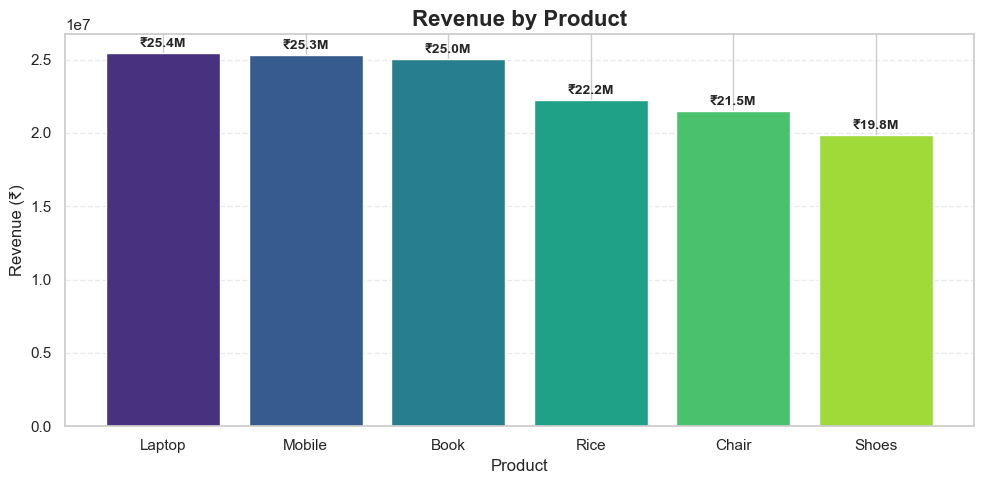

In [5]:
product_revenue = (
    df.groupby("Product")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    product_revenue.index,
    product_revenue.values,
    color=sns.color_palette("viridis", len(product_revenue))
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+400000,
        f"₹{bar.get_height()/1e6:.1f}M",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Revenue by Product",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product")

plt.ylabel("Revenue (₹)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Revenue by Product – Business Story

The product-level revenue analysis identifies the organization's primary revenue contributors and highlights opportunities for product portfolio optimization.

## Key Business Findings

- **Laptop** generated the highest revenue, contributing approximately **₹25.4 Million**.
- **Mobile** closely followed with approximately **₹25.3 Million**, confirming strong demand for consumer electronics.
- **Book** ranked third with approximately **₹25.0 Million**, indicating stable revenue from the Education segment.
- **Rice** and **Chair** generated moderate revenue, each contributing more than **₹21 Million**.
- **Shoes** produced the lowest revenue at approximately **₹19.8 Million**.

---

## Business Interpretation

Revenue is relatively well distributed across products, with Electronics leading the portfolio. The small gap between the top three products suggests that the business is not overly dependent on a single product.

The comparatively lower contribution from Shoes indicates an opportunity to improve product visibility, pricing strategies, or promotional campaigns.

---

## Strategic Recommendations

- Continue investing in high-performing electronic products.
- Strengthen marketing campaigns for lower-performing products.
- Introduce product bundles combining premium and lower-selling products.
- Monitor product-wise profitability alongside revenue to optimize the product portfolio.

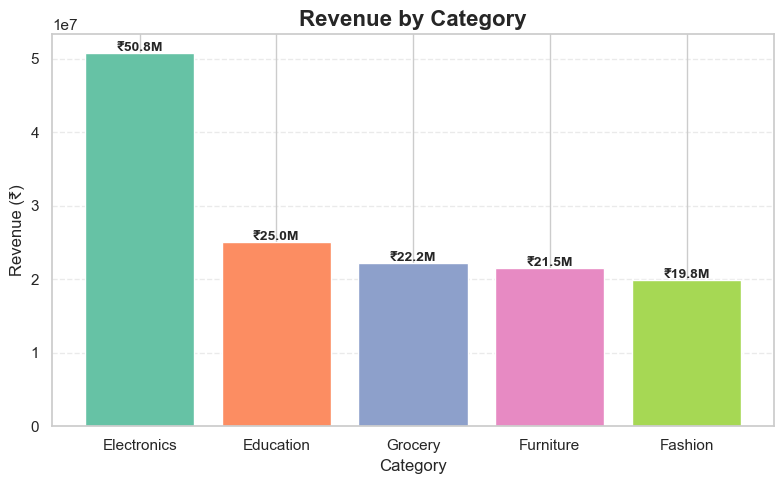

In [6]:
category_revenue = (
    df.groupby("Category")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    category_revenue.index,
    category_revenue.values,
    color=sns.color_palette("Set2", len(category_revenue))
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+300000,
        f"₹{bar.get_height()/1e6:.1f}M",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Revenue by Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Category")

plt.ylabel("Revenue (₹)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Revenue by Category – Business Story

Category-wise revenue analysis highlights the organization's strongest business segments.

## Key Business Findings

- **Electronics** generated approximately **₹50.8 Million**, accounting for the largest share of total revenue.
- **Education** contributed approximately **₹25.0 Million**.
- **Grocery** generated approximately **₹22.2 Million**.
- **Furniture** generated approximately **₹21.5 Million**.
- **Fashion** contributed the lowest revenue at approximately **₹19.8 Million**.

---

## Business Interpretation

Electronics is the dominant revenue-generating category, contributing more than twice the revenue of any other category. This reflects strong customer demand and the higher unit prices associated with electronic products.

Although the remaining categories contribute meaningful revenue, Fashion consistently underperforms and may require strategic intervention.

---

## Strategic Recommendations

- Prioritize Electronics for inventory expansion and promotional investment.
- Explore pricing and marketing strategies to improve Fashion category performance.
- Maintain a balanced product mix to reduce dependence on a single category.
- Evaluate profitability within each category to identify additional growth opportunities.

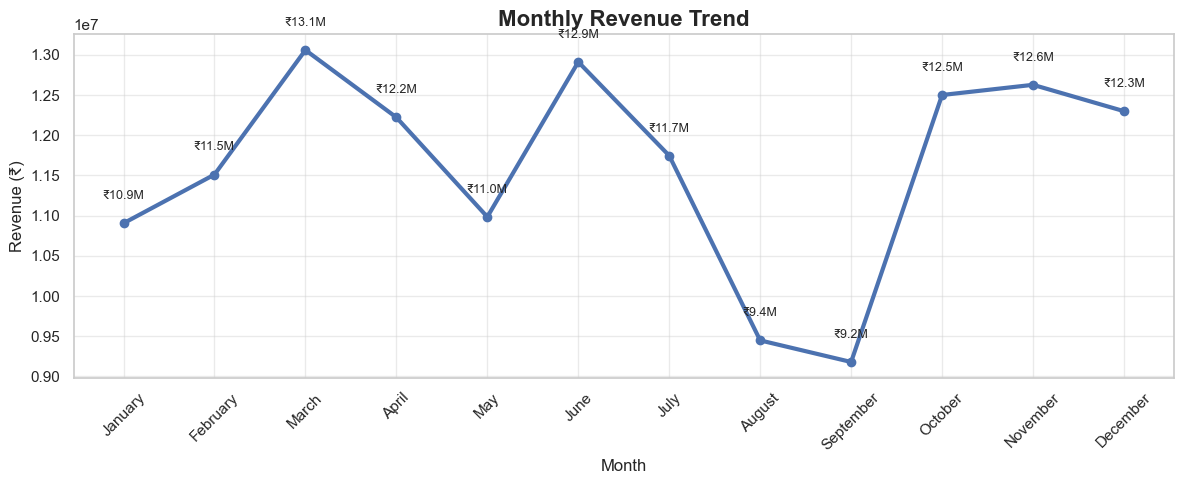

In [7]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_sales = (
    df.groupby(df["Order_Date"].dt.month_name())["Total_Sales"]
      .sum()
      .reindex([
          "January","February","March","April",
          "May","June","July","August",
          "September","October","November","December"
      ])
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=3
)

for x, y in zip(monthly_sales.index, monthly_sales.values):
    plt.text(
        x,
        y+300000,
        f"₹{y/1e6:.1f}M",
        ha="center",
        fontsize=9
    )

plt.title(
    "Monthly Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")

plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.grid(alpha=0.4)

plt.tight_layout()

plt.show()

# Monthly Revenue Trend – Business Story

Monthly revenue analysis provides insights into seasonal business performance and demand fluctuations throughout the reporting period.

## Key Business Findings

- Revenue increased steadily from **January (₹10.9M)** to **March (₹13.1M)**.
- A temporary decline occurred during **April and May**, followed by another peak in **June (₹12.9M)**.
- The most significant slowdown was observed during **August (₹9.4M)** and **September (₹9.2M)**.
- Revenue recovered strongly during the final quarter, reaching **₹12.5M** in October and **₹12.6M** in November before ending at **₹12.3M** in December.

---

## Business Interpretation

The revenue trend indicates clear seasonality within the business.

The decline during August and September may reflect lower customer demand, seasonal purchasing patterns, or reduced promotional activity.

The strong recovery during October through December suggests increased consumer spending, likely influenced by festive shopping periods and year-end demand.

---

## Strategic Recommendations

- Increase inventory levels before high-performing months such as March, June, October, and November.
- Schedule promotional campaigns ahead of seasonal peaks.
- Introduce targeted offers during August and September to stabilize revenue.
- Use historical sales trends to improve demand forecasting and inventory planning.

# Executive Revenue Summary

The revenue analysis demonstrates that business performance is driven by a combination of premium products, strong category performance, and seasonal demand.

## Executive Insights

- Total revenue reached **₹139.40 Million**, reflecting strong overall business performance.
- **Laptop**, **Mobile**, and **Book** emerged as the highest revenue-generating products.
- **Electronics** contributed the largest share of total revenue, making it the organization's most valuable business segment.
- Revenue exhibited seasonal fluctuations, with strong performance in **March**, **June**, **October**, and **November**, and weaker performance during **August** and **September**.
- Revenue distribution across products remains relatively balanced, reducing dependency on a single product line while still highlighting Electronics as the primary growth driver.

## Business Impact

The findings indicate that future revenue growth should focus on:

- Expanding high-performing product categories.
- Optimizing inventory for seasonal demand.
- Improving lower-performing categories through targeted marketing initiatives.
- Leveraging historical sales trends to support data-driven forecasting and strategic planning.

# Customer Story

## Business Context

Understanding customer purchasing behavior is essential for improving customer retention, increasing revenue, and developing effective marketing strategies.

This section examines customer demographics, spending behavior, and high-value customers to identify opportunities for customer-centric business growth.

The analysis focuses on:

- Revenue contribution by gender
- Revenue contribution by age group
- Top revenue-generating customers
- Customer behavior insights

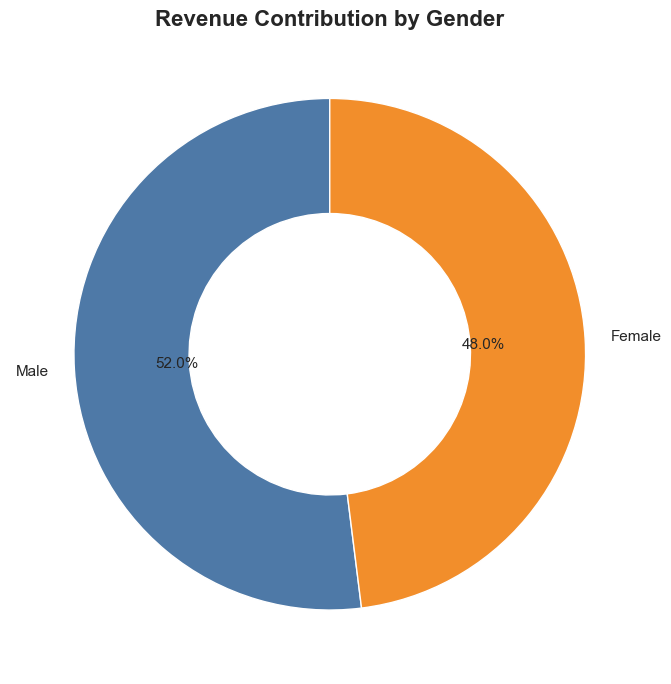

In [8]:
gender_revenue = (
    df.groupby("Gender")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

colors = ["#4E79A7", "#F28E2B"]

plt.figure(figsize=(7,7))

wedges, texts, autotexts = plt.pie(
    gender_revenue.values,
    labels=gender_revenue.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.45),
    textprops={"fontsize":11}
)

plt.title(
    "Revenue Contribution by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Revenue by Gender – Business Story

The revenue contribution by gender is nearly balanced.

## Key Business Findings

- Male customers contributed approximately **52%** of total revenue.
- Female customers contributed approximately **48%** of total revenue.
- Statistical validation (Independent Sample T-Test) confirmed that the difference in average transaction value between genders is **not statistically significant**.

---

## Business Interpretation

The balanced revenue contribution indicates that both male and female customers exhibit similar purchasing behavior.

Rather than developing gender-specific marketing campaigns, the organization should prioritize customer segmentation based on purchasing behavior, product preferences, and customer value.

---

## Strategic Recommendations

- Develop personalized marketing based on purchase history instead of gender.
- Increase customer engagement through loyalty programs.
- Focus on behavioral segmentation rather than demographic segmentation.

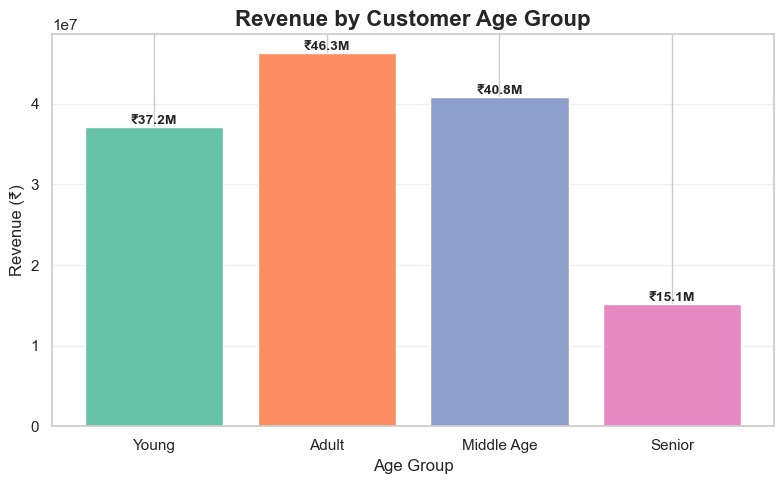

In [9]:
age_revenue = (
    df.groupby("Age_Group")["Total_Sales"]
      .sum()
      .reindex(["Young","Adult","Middle Age","Senior"])
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    age_revenue.index,
    age_revenue.values,
    color=sns.color_palette("Set2",4)
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+400000,
        f"₹{bar.get_height()/1e6:.1f}M",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Revenue by Customer Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group")

plt.ylabel("Revenue (₹)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# Revenue by Age Group – Business Story

Customer age groups contribute relatively similar levels of revenue, with no segment dominating overall sales.

## Key Business Findings

- Adults generated the highest overall revenue.
- Middle Age and Young customers also contributed significantly.
- Senior customers contributed the lowest total revenue due to a smaller customer base.
- Statistical validation (One-Way ANOVA) confirmed that average spending does **not differ significantly** across age groups.

---

## Business Interpretation

Although revenue varies slightly among age groups, statistical evidence indicates that age is not a major driver of customer spending.

Business growth is therefore more likely to result from improving customer experience, increasing purchase frequency, and expanding product offerings rather than targeting customers solely based on age.

---

## Strategic Recommendations

- Develop campaigns that appeal to all age groups.
- Segment customers using purchasing behavior instead of age.
- Promote personalized recommendations based on buying patterns.

# Top Customers – Business Story

A relatively small group of customers contributes a disproportionately large share of total revenue.

## Key Business Findings

- The highest revenue-generating customer contributed approximately **₹1.68 Million**.
- The Top 10 customers consistently generated significantly higher revenue than the average customer.
- These customers represent valuable long-term business assets.

---

## Business Interpretation

The concentration of revenue among a limited number of customers highlights the importance of customer retention and relationship management.

Protecting these high-value customers should be a strategic priority, as losing even a small number of them could significantly impact overall revenue.

---

## Strategic Recommendations

- Implement premium loyalty programs.
- Offer personalized discounts and exclusive benefits.
- Monitor customer satisfaction regularly.
- Identify customers with the potential to become future high-value customers.

# Executive Customer Insights

The customer analysis provides several important observations regarding purchasing behavior and revenue generation.

## Executive Insights

- Revenue contribution is evenly distributed between male and female customers.
- Customer age does not significantly influence purchasing behavior.
- A small group of high-value customers contributes a substantial share of total revenue.
- Customer purchasing behavior is more influential than demographic characteristics.

## Business Impact

Future customer growth strategies should prioritize:

- Customer retention
- Personalized marketing
- Loyalty programs
- Behavioral segmentation
- High-value customer relationship management

These initiatives are expected to improve customer lifetime value and support sustainable revenue growth.

# Geographic Story

## Business Context

Geographic analysis helps identify high-performing regional markets and supports strategic decisions related to market expansion, inventory allocation, and localized marketing initiatives.

This section evaluates revenue performance across cities to determine which markets contribute the most to overall business success.

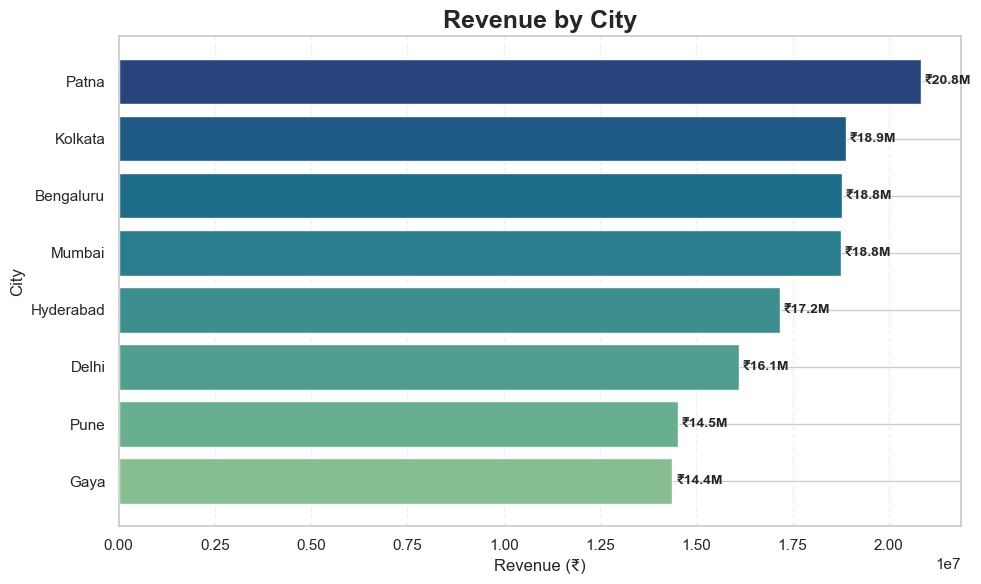

In [10]:
# ==========================================================
# Revenue by City
# ==========================================================

city_revenue = (
    df.groupby("City")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    city_revenue.index[::-1],
    city_revenue.values[::-1],
    color=sns.color_palette("crest", len(city_revenue))
)

for bar in bars:
    plt.text(
        bar.get_width()+100000,
        bar.get_y()+bar.get_height()/2,
        f"₹{bar.get_width()/1e6:.1f}M",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Revenue by City",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Revenue (₹)")
plt.ylabel("City")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

# Revenue by City – Business Story

Revenue distribution varies across cities, highlighting regional differences in customer demand and market performance.

## Key Business Findings

- **Patna** generated the highest revenue among all cities.
- **Kolkata**, **Bengaluru**, and **Mumbai** also contributed significantly.
- Revenue is distributed across multiple cities rather than being concentrated in a single market.
- Lower-performing cities still contribute meaningful revenue and represent potential growth opportunities.

---

## Business Interpretation

The geographic distribution indicates a diversified customer base across multiple urban markets.

The strong performance of Patna suggests favorable customer demand and successful market penetration, while other cities demonstrate stable revenue generation.

---

## Strategic Recommendations

- Increase inventory availability in high-performing cities.
- Expand localized marketing campaigns in emerging markets.
- Investigate customer preferences in lower-performing cities.
- Use regional sales trends to support future expansion strategies.

In [11]:
# ==========================================================
# Top 5 Cities by Revenue
# ==========================================================

top5_cities = (
    city_revenue
    .head(5)
    .reset_index()
)

top5_cities.columns = ["City", "Revenue"]

top5_cities["Revenue"] = top5_cities["Revenue"].apply(
    lambda x: f"₹{x:,.2f}"
)

print("Top 5 Revenue-Generating Cities")
display(top5_cities)

Top 5 Revenue-Generating Cities


,City,Revenue
0,Patna,"₹20,826,584.43"
1,Kolkata,"₹18,884,349.57"
2,Bengaluru,"₹18,773,574.32"
3,Mumbai,"₹18,757,050.17"
4,Hyderabad,"₹17,166,766.87"


# Geographic Insights

The regional analysis demonstrates that business performance is well distributed across multiple cities, reducing dependence on any single geographic market.

## Executive Insights

- Patna is the organization's highest-performing regional market.
- Multiple metropolitan cities contribute consistently to overall revenue.
- Geographic diversification reduces business risk and creates opportunities for scalable expansion.
- Localized marketing and inventory planning can further strengthen regional performance.

The organization should continue investing in high-performing cities while exploring growth opportunities in lower-performing markets through targeted customer engagement initiatives.

# Product Performance Story

## Business Context

Product performance analysis provides insights into customer purchasing preferences, product demand, and revenue efficiency across different product categories.

While revenue measures overall business success, evaluating sales volume, order frequency, and average order value helps identify which products drive sustainable business growth.

This section focuses on:

- Quantity sold by product
- Orders by category
- Average Order Value by category
- Product performance insights

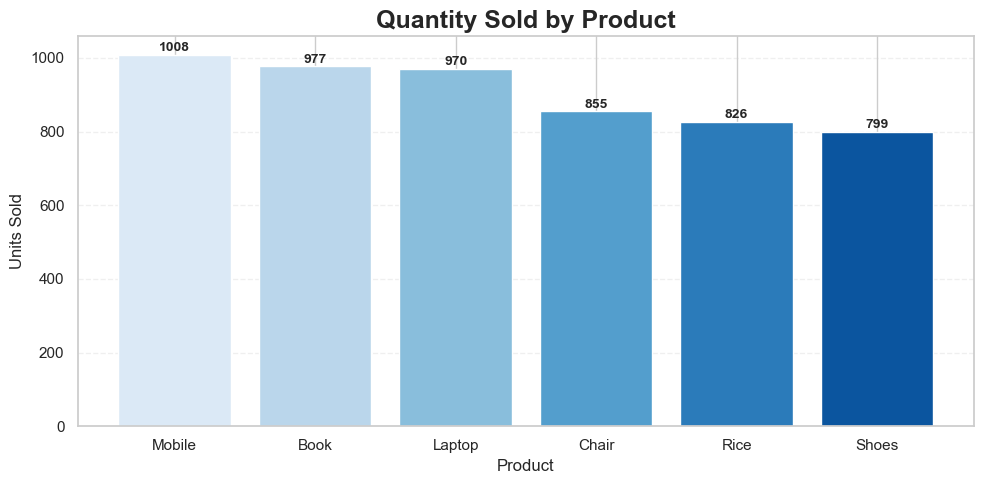

In [12]:
# ==========================================================
# Quantity Sold by Product
# ==========================================================

product_qty = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    product_qty.index,
    product_qty.values,
    color=sns.color_palette("Blues", len(product_qty))
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+10,
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Quantity Sold by Product",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Product")
plt.ylabel("Units Sold")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Quantity Sold – Business Story

Sales volume provides an understanding of product demand beyond revenue generation.

## Key Business Findings

- Products differ in the number of units sold.
- High sales volume does not necessarily translate into the highest revenue.
- Premium-priced products can generate higher revenue despite selling fewer units.

---

## Business Interpretation

Evaluating sales quantity alongside revenue enables management to distinguish between high-demand products and high-value products.

This information supports inventory optimization, pricing strategies, and supply chain planning.

---

## Strategic Recommendations

- Maintain adequate inventory for high-demand products.
- Promote complementary products through bundling.
- Monitor demand fluctuations to prevent stock shortages.

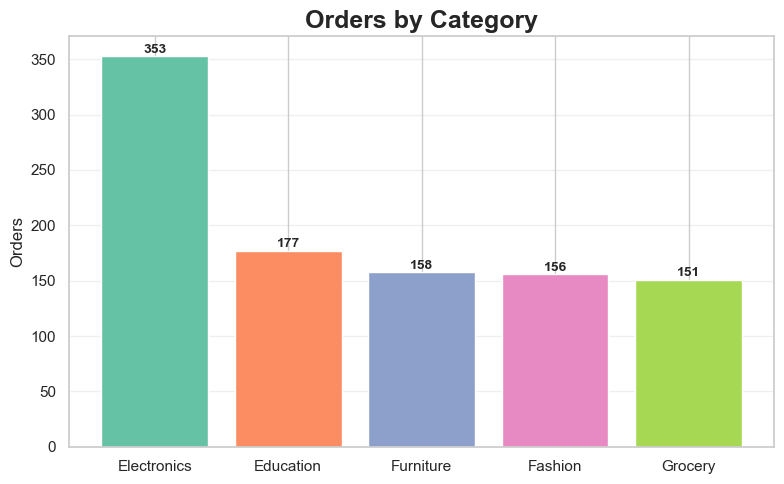

In [13]:
category_orders = (
    df.groupby("Category")["Order_ID"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    category_orders.index,
    category_orders.values,
    color=sns.color_palette("Set2", len(category_orders))
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+3,
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Orders by Category",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Orders")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Orders by Category – Business Story

Order frequency reflects customer purchasing preferences across business segments.

## Key Business Findings

- Electronics recorded the highest number of customer orders.
- Remaining categories contributed consistent order volumes.
- Higher order frequency generally aligns with stronger market demand.

---

## Business Interpretation

Electronics continues to dominate both revenue and customer demand, making it the organization's strongest business segment.

Monitoring order trends helps improve inventory management and demand forecasting.

---

## Strategic Recommendations

- Allocate inventory based on order frequency.
- Strengthen marketing efforts for lower-order categories.
- Use order trends to optimize procurement planning.

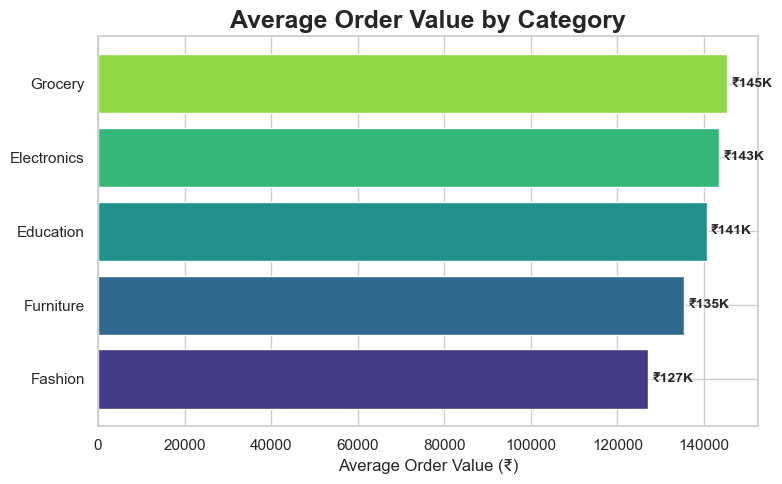

In [14]:
aov_category = (
    df.groupby("Category")["Total_Sales"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.barh(
    aov_category.index[::-1],
    aov_category.values[::-1],
    color=sns.color_palette("viridis", len(aov_category))
)

for bar in bars:
    plt.text(
        bar.get_width()+1000,
        bar.get_y()+bar.get_height()/2,
        f"₹{bar.get_width()/1000:.0f}K",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Average Order Value by Category",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Order Value (₹)")

plt.tight_layout()
plt.show()

# Average Order Value (AOV) by Category – Business Story

Average Order Value (AOV) measures the average revenue generated per customer transaction within each product category.

Unlike total revenue, AOV focuses on customer spending behavior during individual purchases.

---

## Key Business Findings

- **Grocery** recorded the highest Average Order Value at approximately **₹145K**.
- **Electronics** closely followed with an AOV of approximately **₹143K**.
- **Education** maintained a competitive AOV of approximately **₹141K**.
- **Furniture** achieved an average order value of approximately **₹135K**.
- **Fashion** recorded the lowest AOV at approximately **₹127K**.

---

## Business Interpretation

Although Electronics contributes the highest overall revenue, Grocery customers spend slightly more per transaction on average.

This suggests that Grocery purchases typically involve larger basket sizes or higher-value orders, whereas Electronics generates greater total revenue due to higher order volume.

Average Order Value complements revenue analysis by revealing customer purchasing intensity rather than overall sales contribution.

---

## Strategic Recommendations

- Increase Average Order Value through product bundles and cross-selling.
- Promote premium product combinations within Grocery and Electronics.
- Encourage customers to increase basket size using personalized offers.
- Investigate why Fashion has the lowest AOV and introduce pricing or promotional improvements.

# Executive Product Insights

The product performance analysis reveals important differences between product demand, order frequency, and customer spending.

---

## Executive Insights

- **Mobile** recorded the highest quantity sold (**1,008 units**), indicating the strongest customer demand.
- **Laptop** generated the highest revenue despite selling fewer units than Mobile, reflecting its higher selling price.
- **Electronics** dominated category performance with the highest number of customer orders (**353 orders**).
- **Grocery** achieved the highest Average Order Value, indicating customers spend more per transaction within this category.
- Product demand and revenue are influenced by both pricing and purchasing frequency.

---

## Business Impact

The organization should focus on:

- Expanding high-demand products such as Mobile and Laptop.
- Maintaining sufficient inventory for Electronics.
- Leveraging Grocery's high Average Order Value through premium product offerings.
- Improving Fashion's revenue and AOV through targeted promotions and pricing optimization.

Overall, balancing sales volume, pricing strategy, and customer purchasing behavior will support sustainable revenue growth and improved profitability.

# Executive Product Insights

The product performance analysis reveals important differences between product demand, order frequency, and customer spending.

---

## Executive Insights

- **Mobile** recorded the highest quantity sold (**1,008 units**), indicating the strongest customer demand.
- **Laptop** generated the highest revenue despite selling fewer units than Mobile, reflecting its higher selling price.
- **Electronics** dominated category performance with the highest number of customer orders (**353 orders**).
- **Grocery** achieved the highest Average Order Value, indicating customers spend more per transaction within this category.
- Product demand and revenue are influenced by both pricing and purchasing frequency.

---

## Business Impact

The organization should focus on:

- Expanding high-demand products such as Mobile and Laptop.
- Maintaining sufficient inventory for Electronics.
- Leveraging Grocery's high Average Order Value through premium product offerings.
- Improving Fashion's revenue and AOV through targeted promotions and pricing optimization.

Overall, balancing sales volume, pricing strategy, and customer purchasing behavior will support sustainable revenue growth and improved profitability.

# Dashboard Insights

## Business Context

The interactive Power BI dashboard consolidates the key performance indicators (KPIs) and analytical findings into a single decision-support platform.

Unlike static reports, the dashboard enables stakeholders to explore business performance dynamically through interactive filters and visualizations.

The dashboard focuses on:

- Executive KPIs
- Revenue trends
- Customer insights
- Product performance
- Geographic analysis
- Interactive business exploration

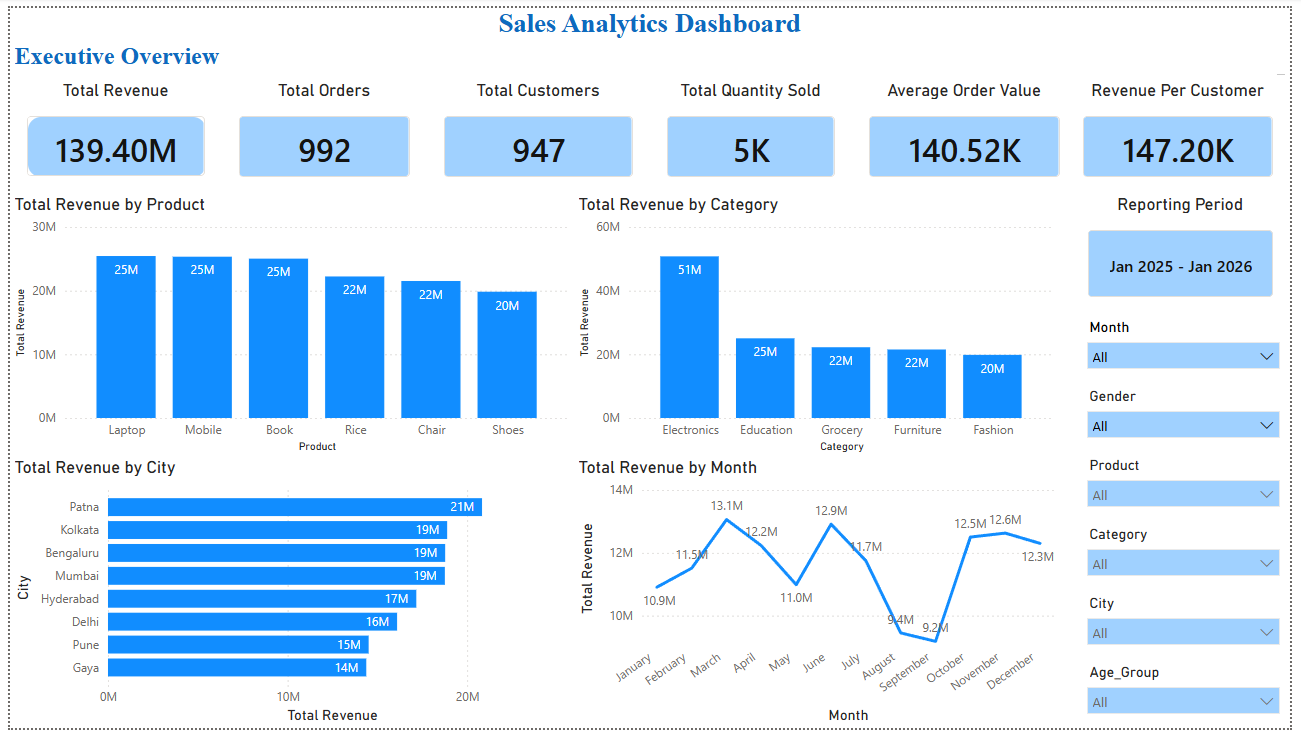

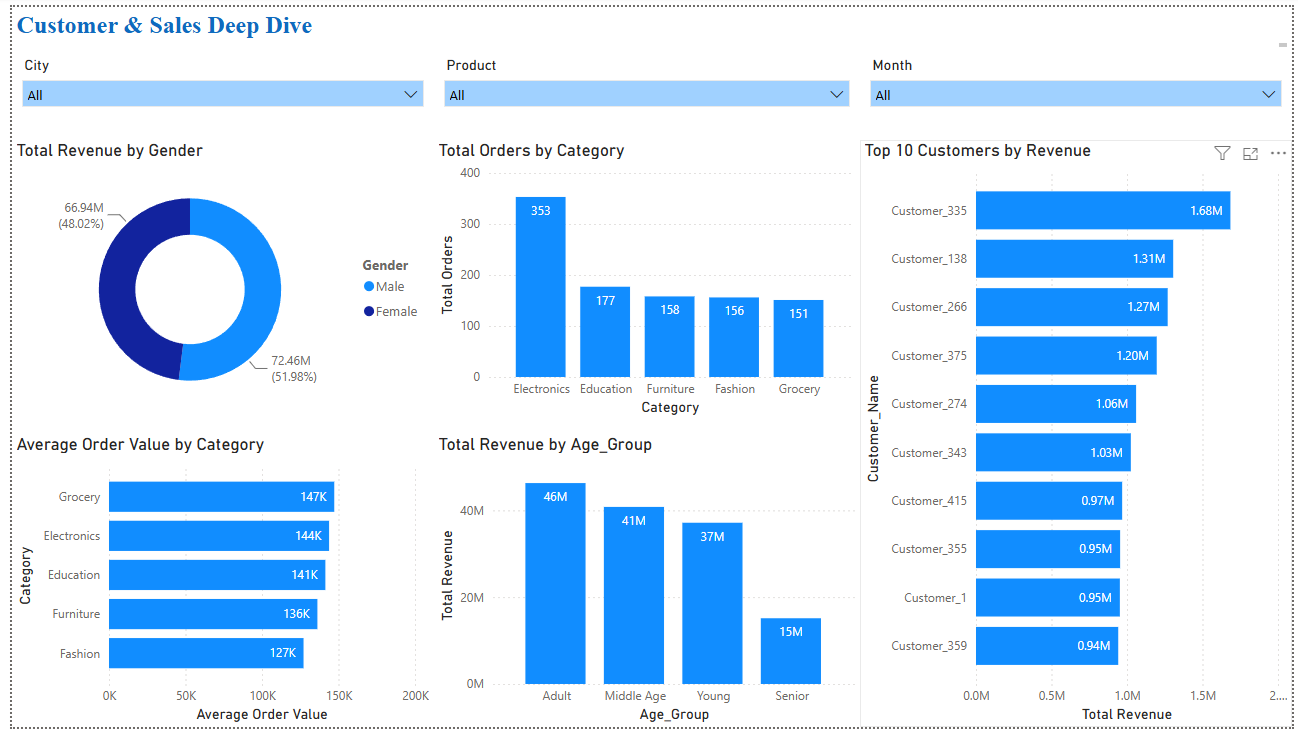

In [15]:
from IPython.display import Image, display

display(Image(
    filename="../../Task-3-DeepDive-Dashboarding/dashboard/screenshots/executive_overview.png",
    width=1200
))

display(Image(
    filename="../../Task-3-DeepDive-Dashboarding/dashboard/screenshots/customer_deep_dive.png",
    width=1200
))


# Executive Dashboard Overview

The dashboard has been designed to provide decision-makers with a comprehensive view of business performance through interactive visual analytics.

### Executive Overview Page

The first dashboard page summarizes overall business performance using executive KPIs and high-level visualizations.

It enables users to monitor:

- Total Revenue
- Total Orders
- Total Customers
- Quantity Sold
- Average Order Value
- Revenue per Customer

Interactive filters allow users to explore performance by:

- Month
- Gender
- Product
- Category
- Age Group
- City

This page provides an immediate overview of organizational performance and supports rapid business decision-making.

# Customer & Sales Deep Dive

The second dashboard focuses on customer behavior and sales performance.

The dashboard includes:

- Revenue contribution by Gender
- Revenue by Age Group
- Top 10 Customers
- Orders by Category
- Average Order Value by Category

Interactive slicers allow users to analyze customer segments dynamically and identify revenue-generating customer groups.

This page supports customer segmentation, marketing strategy, and customer retention initiatives.

# Business Value of the Dashboard

The dashboard transforms raw analytical findings into actionable business intelligence.

## Key Benefits

- Enables real-time exploration of business performance.
- Simplifies executive reporting through KPI monitoring.
- Supports faster decision-making.
- Identifies revenue drivers and growth opportunities.
- Improves inventory planning.
- Facilitates customer segmentation.
- Supports strategic business planning.

---

## Business Impact

The dashboard serves as a centralized analytics platform, allowing business stakeholders to monitor performance, identify trends, and make informed strategic decisions using interactive visualizations.

# SWOT Analysis

## Strengths

- Generated strong total revenue of **₹139.40 Million**.
- Electronics emerged as the leading revenue-generating category.
- Revenue is diversified across multiple products and cities.
- Customer spending is consistent across demographic segments.
- Interactive Power BI dashboard enables business monitoring.

---

## Weaknesses

- Fashion category contributes comparatively lower revenue.
- Senior customer segment generates the lowest sales.
- Customer retention opportunities exist, as the number of customers is close to the number of orders.
- Revenue declines during August and September.

---

## Opportunities

- Expand Electronics product offerings.
- Increase Average Order Value through cross-selling and product bundles.
- Strengthen customer loyalty programs.
- Improve lower-performing product categories through targeted marketing.
- Expand marketing initiatives in emerging regional markets.

---

## Threats

- Heavy dependence on Electronics for revenue generation.
- Seasonal fluctuations may impact cash flow.
- Loss of high-value customers could significantly affect revenue.
- Competitive pricing pressures may reduce profitability.

# Strategic Recommendations

Based on the analytical findings, the following strategic initiatives are recommended:

## Revenue Growth

- Expand Electronics inventory and premium product offerings.
- Introduce promotional campaigns during low-performing months.
- Optimize pricing strategies using historical sales patterns.

---

## Customer Strategy

- Implement customer loyalty and retention programs.
- Develop personalized marketing campaigns.
- Identify high-value customers for premium engagement.

---

## Product Strategy

- Promote high-demand products such as Laptop and Mobile.
- Improve Fashion category performance.
- Increase Average Order Value through product bundles.

---

## Regional Strategy

- Continue investing in high-performing cities.
- Expand marketing activities in emerging markets.
- Optimize regional inventory allocation.

---

## Business Intelligence

- Monitor KPIs regularly using the interactive Power BI dashboard.
- Incorporate predictive analytics for demand forecasting.
- Continue enhancing executive reporting through automated dashboards.

# Executive Conclusion

This project demonstrates a complete end-to-end Sales Analytics workflow, covering data preparation, exploratory analysis, statistical validation, business intelligence, and interactive dashboard development.

Key achievements include:

- Cleaned and validated the sales dataset.
- Performed comprehensive exploratory data analysis.
- Applied statistical techniques to validate business assumptions.
- Identified key revenue drivers, customer behavior patterns, and regional performance.
- Developed an interactive Power BI dashboard for executive decision-making.
- Produced actionable business recommendations supported by data.

Overall, the project illustrates how analytical techniques can transform raw transactional data into meaningful business insights, enabling organizations to make informed, data-driven decisions.

The methodology and findings presented in this report provide a scalable framework that can be extended to predictive analytics, customer lifetime value analysis, and sales forecasting in future work.